## Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:7'

%load_ext autoreload
%autoreload 2

## Data generation

In [2]:
from datasets import Spiral

n, d = 10000, 64                                
true_rho = 0.7                                   # < higher rho, higher MI
v = 3.14/2

dataset = Spiral.Spiral(rho=true_rho, dim=d, v=v)
X, Y = dataset.sample(n=10000)
X, Y = X.to(device).clone().detach(), Y.to(device).clone().detach()


print('X size=', X.size(), 'Y size=', Y.size())
print("True MI is", dataset.MI())

X size= torch.Size([10000, 32]) Y size= torch.Size([10000, 32])
True MI is 10.773512852220248


## Train the VCE estimator

In [3]:
class Hyperparams(object):
    def __init__(self): 
        self.critic = 'neural'                # ('neural', 'quadratic')
        self.lr = 5e-4
        self.bs = 500
        self.n_bridges = 4
        self.wd = 1e-5
        self.max_iteration = 1250
        
hyperparams=Hyperparams()

architecture_critic = [d, 500, 500, 500, 1]

In [4]:
## Neural adaptive MI estimate
from estimators.VCE import VCE

estimator = VCE(None, None, architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(X, Y)

print('true MI:', dataset.MI())
print('est MI:', estimator.MI(X, Y))

K components= 5 copula transform= True
learning marginals...
nde type: FM
finished: t= 0 loss= 2.0027246475219727 loss val= 1.9937608242034912 best val loss= 1.9937608242034912 best t= 0
finished: t= 126 loss= 1.5531693696975708 loss val= 1.6278029680252075 best val loss= 1.580034852027893 best t= 41


finished: t= 0 loss= 2.049119234085083 loss val= 1.9915621280670166 best val loss= 1.9915621280670166 best t= 0
finished: t= 126 loss= 1.5789645910263062 loss val= 1.6578348875045776 best val loss= 1.6336009502410889 best t= 121
finished: t= 252 loss= 1.5831035375595093 loss val= 1.6481577157974243 best val loss= 1.6210055351257324 best t= 182
finished: t= 378 loss= 1.5875093936920166 loss val= 1.6601274013519287 best val loss= 1.6210055351257324 best t= 182


learning copulas...
bs= 4000
finished: t= 0 loss= 451.76007080078125 loss val= 455.32177734375 best val loss= 455.32177734375 best t= 0
finished: t= 101 loss= 79.90733337402344 loss val= 80.13668823242188 best val loss= 80.12653350

### Check the computed vector ranks

In [6]:
import torch.distributions as distribution

XX, YY = estimator.forward(X, Y)

# Compute empirical ranks
sorted_data, idx = torch.sort(XX, dim=0)
_, idx2 = torch.sort(idx, dim=0)
U = (idx2.float()+1)/(len(XX)+1)   

# Compute covariance
zeros, ones = torch.zeros(XX.size()).to(XX.device), torch.ones(XX.size()).to(XX.device)
U = (U-U.mean(keepdim=True, dim=0))/U.std(keepdim=True, dim=0)


V = torch.matmul(U.t(), U)/(len(U)+1)

### Visualizing the distributions of non-diagonal elements

mean abs 0.021701901590397095
q5 -0.03679722175002098
q95 0.033348314464092255


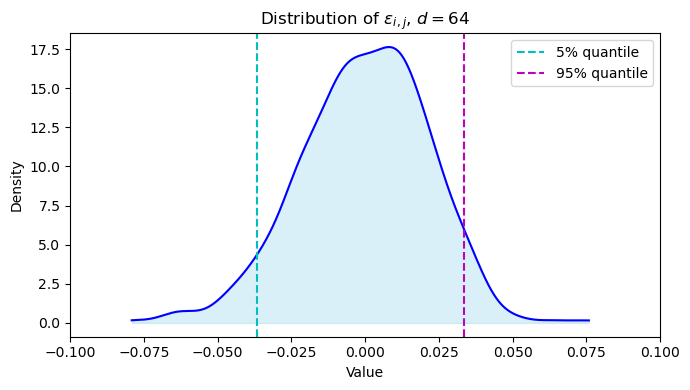

In [7]:
from scipy.stats import gaussian_kde


# Get non-diagonal elements of covariance matrices
non_diag_mask = ~torch.eye(V.size(0), dtype=bool, device=V.device)
non_diag_values = V[non_diag_mask]

# Convert to numpy
non_diag_np = non_diag_values.cpu().numpy()
sorted_vals = np.sort(non_diag_np)

# Compute ranks
L = len(sorted_vals)
q5, q95 = sorted_vals[int(L * 0.05)], sorted_vals[int(L * 0.95)]
print('mean abs', (sorted_vals**2).mean()**0.5)
print('q5', q5.item())
print('q95', q95.item())

# KDE with scipy
kde = gaussian_kde(non_diag_np)
x_vals = np.linspace(min(non_diag_np), max(non_diag_np), 1000)
density = kde(x_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(x_vals, density, color='blue')
plt.fill_between(x_vals, density, alpha=0.3, color='skyblue')
plt.axvline(q5, color='c', linestyle='--', label='5% quantile')
plt.axvline(q95, color='m', linestyle='--', label='95% quantile')
plt.title(r'Distribution of $\epsilon_{i, j}$, $d=64$')
plt.xlim(-0.10, 0.10)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()